# Refugis climàtics i vulnerabilitat social a Barcelona — Anàlisi

Notebook d'anàlisi (parteix de les dades ja netes; la neteja/preparació es documenta a `01_neteja_preparacio_datasets.ipynb`).

**Importem datasets:**
- `01_refugis_climatics_amb_barri.csv`
- `02_poblacio_barri_clean.csv`
- `03_renda_bruta_llar_2023_clean.csv`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from IPython.display import display
import geopandas as gpd

DATA = Path("../1. Data/processed")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

refugis = pd.read_csv(DATA / "01_refugis_climatics_amb_barri.csv")
poblacio = pd.read_csv(DATA / "02_poblacio_barri_clean.csv")
renda = pd.read_csv(DATA / "03_renda_bruta_llar_2023_clean.csv")

print(f"Refugis: {refugis.shape[0]} files")
print(f"Població: {poblacio.shape[0]} barris")
print(f"Renda: {renda.shape[0]} barris")

Refugis: 530 files
Població: 73 barris
Renda: 73 barris


## 0. Context: què diu la ciutat, i què intenta aportar aquest anàlisi

**El relat oficial** (Ajuntament de Barcelona, estiu 2026 — font: [betevé, 18/06/2026](https://beteve.cat/medi-ambient/mapa-refugis-climatics-barcelona/)):
- **Més de 500 refugis climàtics** repartits pels 10 districtes.
- **99% de la població** té un refugi a menys de 10 minuts a peu de casa (baixa a 92,3% un diumenge d'agost, per horaris reduïts).
- Repartiment per districte: Sant Andreu (70), Sant Martí (66), l'Eixample (63), Nou Barris (57), Sants-Montjuïc (54), Horta-Guinardó (50), Ciutat Vella (49), Gràcia (37), Sarrià-Sant Gervasi (30), Les Corts (24).
- L'Ajuntament afirma que **"la xarxa de refugis s'amplia especialment en els barris que tenien menys cobertura i amb més vulnerabilitat davant la calor."**

**El que aquest anàlisi hi aporta:**
1. Els districtes amb bones xifres (Sant Andreu, Sant Martí, Eixample) poden amagar barris concrets desprotegits dins seu — l'agregat per districte no ho revela.
2. No tots els "500+ refugis" són igual d'accessibles: alguns són comerços, piscines de pagament o espais d'ús restringit. Calia definir un criteri operatiu de "refugi real".
3. Comprovem si la promesa de prioritzar barris vulnerables es reflecteix realment en la cobertura actual.

**Criteri de "refugi real" (recordatori, veure neteja per al detall):** 

`Gratuït` distingeix Sí / Parcialment (incentiu comercial sense pagament obligatori per refugiar-s'hi) / No (només Piscina, que sí que cobra entrada). 

`Accés Lliure` distingeix Sí / Parcialment (ús limitat en el temps, no en l'entrada) / Restringit (condicionat, p. ex. socis). Aquestes distincions són deliberades, no valors ambigus.

### 0.1 Validació creuada: els nostres recomptes per districte vs. la xifra publicada a la font de betevé

Abans de continuar, comprovem que les nostres dades s'assemblen a les xifres que citen les fonts oficials. Utilitzem el recompte d'ubicacions úniques (algunes adreces inclouen diversos espais dins del mateix edifici, comptats per separat als registres originals — per exemple, el CCCB té diverses sales llistades individualment). 


In [4]:
MAPA_DISTRICTE = {
    1: "Ciutat Vella", 2: "l'Eixample", 3: "Sants-Montjuïc", 4: "Les Corts",
    5: "Sarrià-Sant Gervasi", 6: "Gràcia", 7: "Horta-Guinardó", 8: "Nou Barris",
    9: "Sant Andreu", 10: "Sant Martí",
}
OFICIAL_DISTRICTE = {
    "Sant Andreu": 70, "Sant Martí": 66, "l'Eixample": 63, "Nou Barris": 57,
    "Sants-Montjuïc": 54, "Horta-Guinardó": 50, "Ciutat Vella": 49,
    "Gràcia": 37, "Sarrià-Sant Gervasi": 30, "Les Corts": 24,
}

refugis_unics = refugis.drop_duplicates(subset=["Latitud", "Longitud"]).copy()
refugis_unics["Nom_Districte"] = refugis_unics["Codi_Districte"].map(MAPA_DISTRICTE)

comparativa = (
    refugis_unics["Nom_Districte"].value_counts()
    .rename("Nostre_recompte")
    .to_frame()
    .assign(Recompte_oficial=lambda d: d.index.map(OFICIAL_DISTRICTE))
    .sort_values("Recompte_oficial", ascending=False)
)

n_nostre = comparativa["Nostre_recompte"].sum()
n_oficial = comparativa["Recompte_oficial"].sum()

# ---------------------------------------------------------------
# Diferència per districte (nostre vs. oficial)
# ---------------------------------------------------------------
comparativa["Diferencia"] = comparativa["Nostre_recompte"] - comparativa["Recompte_oficial"]
comparativa["Diferencia_pct"] = (
    comparativa["Diferencia"] / comparativa["Recompte_oficial"] * 100
).round(1)

# ---------------------------------------------------------------
# Test estadístic d'equivalència — khi-quadrat
# ---------------------------------------------------------------
esperats = comparativa["Recompte_oficial"] / n_oficial * n_nostre 
chi2_stat, p_valor = stats.chisquare(f_obs=comparativa["Nostre_recompte"], f_exp=esperats)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
print(comparativa)
print(f"\nTotal (nostre): {n_nostre}")
print(f"Total (oficial, aprox. 'més de 500'): {n_oficial}")

alpha = 0.05
print(f"\n--- ---")
print(f"p-valor = {p_valor:.4f}")
if p_valor > alpha:
    print(
        "p > 0.05 -> no hi ha evidència estadística de diferència: "
        "el nostre recompte es considera equivalent a l'oficial."
    )
else:
    print(
        "p <= 0.05 -> el nostre recompte difereix significativament de l'oficial "
        "(no es pot considerar equivalent)."
    )

                     Nostre_recompte  Recompte_oficial  Diferencia  Diferencia_pct
Nom_Districte                                                                     
Sant Andreu                       69                70          -1           -1.40
Sant Martí                        68                66           2            3.00
l'Eixample                        69                63           6            9.50
Nou Barris                        59                57           2            3.50
Sants-Montjuïc                    60                54           6           11.10
Horta-Guinardó                    49                50          -1           -2.00
Ciutat Vella                      45                49          -4           -8.20
Gràcia                            36                37          -1           -2.70
Sarrià-Sant Gervasi               32                30           2            6.70
Les Corts                         25                24           1            4.20

Tot

## 1. Panorama de refugis per categoria

Distribució dels 512 refugis (ubicacions úniques) per categoria, i quants d'ells compleixen el criteri de "refugi real" (Gratuït=Sí i Accés Lliure=Sí).

                       n_total  n_real  pct_real
Categoria                                       
Microrefugi                 93       0      0.00
Biblioteca                  48      48    100.00
Centre Cívic                47      47    100.00
Parc i Jardí                47      47    100.00
Piscina                     44       0      0.00
Casal de Gent Gran          32       0      0.00
Complex Esportiu            31       0      0.00
Casal de Barri              28      28    100.00
Mercat                      20       0      0.00
Joc d'Aigua                 19      19    100.00
Interior d'Illa             14      14    100.00
Pati d'Escola               13       0      0.00
Museu                       12       0      0.00
Equipament de Ciutat        11       0      0.00
Entitat Cultural            10      10    100.00
Pati d'Escola Bressol       10       0      0.00
Centre de Culte             10       0      0.00
Equipament Sanitari          6       0      0.00
Espai Jove          

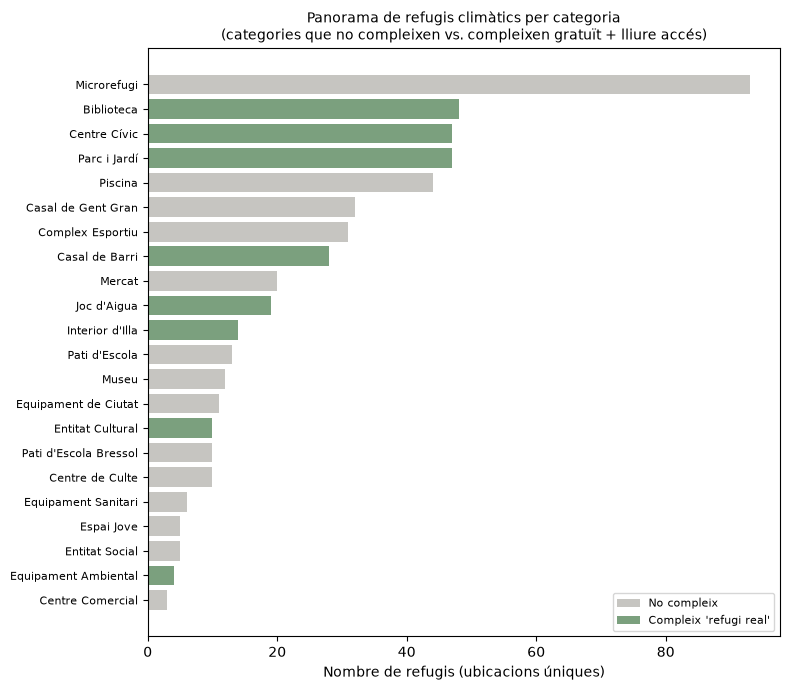

In [30]:
panorama = (
    refugis_unics.groupby("Categoria")
    .agg(
        n_total=("Nom", "count"),
        n_real=("Nom", lambda x: ((refugis_unics.loc[x.index, "Gratuït"] == "Sí") &
                                    (refugis_unics.loc[x.index, "Accés Lliure"] == "Sí")).sum()),
    )
    .assign(pct_real=lambda d: (d["n_real"] / d["n_total"] * 100).round(1))
    .sort_values("n_total", ascending=False)
)

print(panorama)

fig, ax = plt.subplots(figsize=(8, 7))
panorama_sorted = panorama.sort_values("n_total")
ax.barh(panorama_sorted.index, panorama_sorted["n_total"], color="#C6C5C1", label="No compleix")
ax.barh(panorama_sorted.index, panorama_sorted["n_real"], color="#7BA07E", label="Compleix 'refugi real'")
ax.set_xlabel("Nombre de refugis (ubicacions úniques)")
ax.set_title("Panorama de refugis climàtics per categoria\n(categories que no compleixen vs. compleixen gratuït + lliure accés)", fontsize=10)
ax.legend(fontsize=8, loc="lower right")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

## 2. Cobertura real: caiguda brut → filtrat per barri

Comptem refugis per barri de dues maneres: **brut** (totes les ubicacions úniques) i **filtrat** (només Gratuït=Sí i Accés Lliure=Sí). Seleccionem els barris amb un mínim de 5 refugis bruts per veure caigudes reals i evitar que un barri amb 1 o 2 refugis surti amb caigudes percentuals exagerades per pur soroll estadístic.

Ubicacions úniques (brut): 512
Ubicacions úniques (filtrat): 217
Reducció: 57.6%


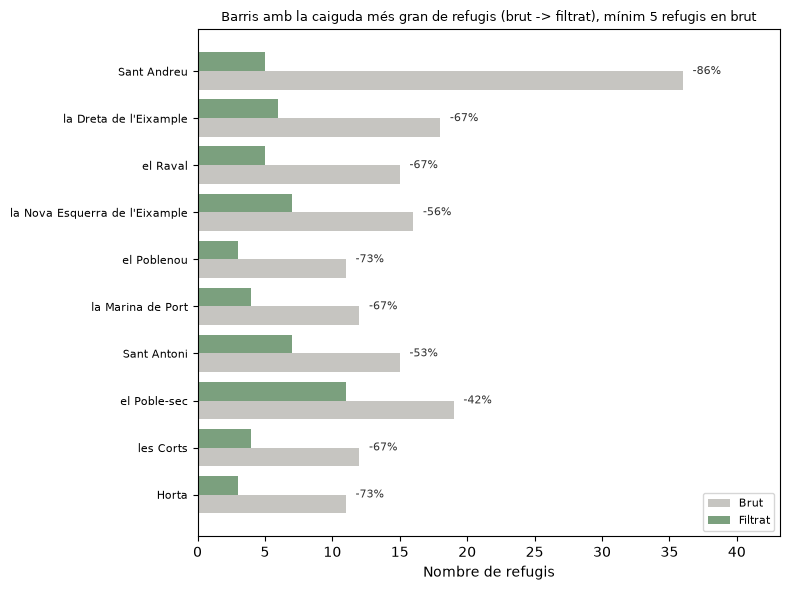

In [31]:
n_brut = refugis_unics.groupby("Codi_Barri").size().rename("n_refugis_brut")

refugis_filtrats = refugis[(refugis["Gratuït"] == "Sí") & (refugis["Accés Lliure"] == "Sí")]
refugis_filtrats_unics = refugis_filtrats.drop_duplicates(subset=["Latitud", "Longitud"])
n_filtrat = refugis_filtrats_unics.groupby("Codi_Barri").size().rename("n_refugis_filtrat")

print(f"Ubicacions úniques (brut): {len(refugis_unics)}")
print(f"Ubicacions úniques (filtrat): {len(refugis_filtrats_unics)}")
print(f"Reducció: {(1 - len(refugis_filtrats_unics)/len(refugis_unics))*100:.1f}%")

cobertura = poblacio[["Codi_Barri", "Nom_Barri"]].merge(n_brut, on="Codi_Barri", how="left")
cobertura = cobertura.merge(n_filtrat, on="Codi_Barri", how="left")
cobertura["n_refugis_brut"] = cobertura["n_refugis_brut"].fillna(0).astype(int)
cobertura["n_refugis_filtrat"] = cobertura["n_refugis_filtrat"].fillna(0).astype(int)
cobertura["caiguda_absoluta"] = cobertura["n_refugis_brut"] - cobertura["n_refugis_filtrat"]
cobertura["caiguda_pct"] = (cobertura["caiguda_absoluta"] / cobertura["n_refugis_brut"] * 100).round(1)

robust = cobertura[cobertura["n_refugis_brut"] >= 5].sort_values("caiguda_absoluta", ascending=False)
top10 = robust.head(10).sort_values("caiguda_absoluta")

fig, ax = plt.subplots(figsize=(8, 6))
y = range(len(top10))
ax.barh([p - 0.2 for p in y], top10["n_refugis_brut"], height=0.4, label="Brut", color="#C6C5C1")
ax.barh([p + 0.2 for p in y], top10["n_refugis_filtrat"], height=0.4, label="Filtrat", color="#7BA07E")

max_x = top10[["n_refugis_brut", "n_refugis_filtrat"]].max().max()
ax.set_xlim(0, max_x * 1.2)
for i, (_, row) in enumerate(top10.iterrows()):
    x_text = max(row["n_refugis_brut"], row["n_refugis_filtrat"]) + max_x * 0.02
    ax.text(x_text, i, f"-{row['caiguda_pct']:.0f}%", va="center", fontsize=8, color="#333333")

ax.set_yticks(list(y))
ax.set_yticklabels(top10["Nom_Barri"], fontsize=8)
ax.set_xlabel("Nombre de refugis")
ax.set_title("Barris amb la caiguda més gran de refugis (brut -> filtrat), mínim 5 refugis en brut", fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


Per identificar l'origen de la caiguda de cobertura en els barris més afectats pel filtre de qualitat, s'ha calculat, per a cadascun dels 10 barris amb major reducció, la categoria d'equipament que concentra el major nombre de refugis exclosos. 

Es defineix una categoria com a predominant quan explica un mínim del 50% de la caiguda total del barri; per sota d'aquest llindar, la pèrdua es considera distribuïda entre diverses categories.

In [42]:
refugis_no_compleix = refugis_unics[
    ~((refugis_unics["Gratuït"] == "Sí") & (refugis_unics["Accés Lliure"] == "Sí"))
]

categoria_predominant = (
    refugis_no_compleix[refugis_no_compleix["Codi_Barri"].isin(top10["Codi_Barri"])]
    .groupby(["Codi_Barri", "Categoria"])
    .size()
    .rename("n_categoria")
    .reset_index()
    .sort_values(["Codi_Barri", "n_categoria"], ascending=[True, False])
    .drop_duplicates(subset="Codi_Barri", keep="first")
)

categoria_predominant = categoria_predominant.merge(
    top10[["Codi_Barri", "Nom_Barri", "caiguda_absoluta", "caiguda_pct"]],
    on="Codi_Barri",
)
categoria_predominant["pes_categoria_pct"] = (
    categoria_predominant["n_categoria"] / categoria_predominant["caiguda_absoluta"] * 100
).round(1)
categoria_predominant = categoria_predominant.sort_values("caiguda_absoluta", ascending=False).reset_index(drop=True)
categoria_predominant = categoria_predominant.rename(columns={
    "n_categoria": "categoria_n_refugis",
    "caiguda_absoluta": "total_n_refugis",
})

es_predominant = categoria_predominant["pes_categoria_pct"] >= 50

taula_display = categoria_predominant[
    ["Nom_Barri", "Categoria", "categoria_n_refugis", "total_n_refugis", "caiguda_pct"]
]

def highlight_predominant(row):
    color = "#C9772F" if es_predominant[row.name] else "#E7E4DB"
    return [f"background-color: {color}; color: #2c2c2a"] * len(row)

taula_estil = (
    taula_display.style
    .apply(highlight_predominant, axis=1)
    .format({"caiguda_pct": "{:.1f}%"})
    .hide(axis="index")
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#4a4a4a"), ("color", "white"),
            ("padding", "6px 10px"), ("text-align", "center"), ("white-space", "nowrap"),
        ]},
        {"selector": "td", "props": [
            ("padding", "6px 10px"), ("text-align", "center"), ("border", "1px solid #ddd"),
            ("white-space", "nowrap"),
        ]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "11px"), ("padding-bottom", "6px")]},
    ])
 .set_caption("Categoria predominant en la caiguda de refugis, per barri (top 10).<br>"
                 "Taronja = una sola categoria explica ≥50% de la caiguda del barri.")
)

taula_estil



Nom_Barri,Categoria,categoria_n_refugis,total_n_refugis,caiguda_pct
Sant Andreu,Microrefugi,25,31,86.1%
la Dreta de l'Eixample,Microrefugi,6,12,66.7%
el Raval,Casal de Gent Gran,2,10,66.7%
la Nova Esquerra de l'Eixample,Casal de Gent Gran,2,9,56.2%
Sant Antoni,Microrefugi,6,8,53.3%
el Poble-sec,Microrefugi,2,8,42.1%
la Marina de Port,Casal de Gent Gran,3,8,66.7%
les Corts,Microrefugi,2,8,66.7%
Horta,Microrefugi,4,8,72.7%
el Poblenou,Complex Esportiu,3,8,72.7%


## 3. Índex de vulnerabilitat (renda + edat, percentil)

- Indicador demogràfic combinat: `pct_65_mes + pct_menys_5` (OMS: gent gran i infants són els dos grups de risc fisiològic davant la calor).
- Normalització per **percentil**, no min-max — més robust davant outliers (p. ex. la Clota).
- Índex = 50% renda invertida + 50% edat de risc.

In [8]:
idx = poblacio.merge(renda[["Codi_Barri", "Renda_Bruta_Mediana"]], on="Codi_Barri", how="left")
assert idx.shape[0] == 73
assert idx["Renda_Bruta_Mediana"].isnull().sum() == 0

idx["pct_vulnerable_fisiologic"] = idx["pct_65_mes"] + idx["pct_menys_5"]
idx["renda_percentil"] = idx["Renda_Bruta_Mediana"].rank(pct=True)
idx["edat_percentil"] = idx["pct_vulnerable_fisiologic"].rank(pct=True)
idx["index_vulnerabilitat"] = 0.5 * (1 - idx["renda_percentil"]) + 0.5 * idx["edat_percentil"]

idx = idx.sort_values("index_vulnerabilitat", ascending=False).reset_index(drop=True)
idx["ranking_vulnerabilitat"] = idx.index + 1

columnes_csv = [
    "ranking_vulnerabilitat", "Codi_Barri", "Nom_Barri",
    "pct_vulnerable_fisiologic", "Renda_Bruta_Mediana", "index_vulnerabilitat",
]
idx[columnes_csv].to_csv("ranking_vulnerabilitat_barris.csv", index=False)


In [43]:
taula = idx[["Nom_Barri", "pct_vulnerable_fisiologic", "Renda_Bruta_Mediana", "index_vulnerabilitat"]].head(10)

(
    taula.style
    .set_caption("Top 10 barris més vulnerables per índex de vulnerabilitat")
    .format({
        "pct_vulnerable_fisiologic": "{:.2f}%",
        "Renda_Bruta_Mediana": "{:,.2f} €",
        "index_vulnerabilitat": "{:.2f}",
    })
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#4a4a4a"),
                                      ("color", "white"),
                                      ("text-align", "center"),
                                      ("font-weight", "bold")]},
        {"selector": "caption", "props": [("font-size", "14px"),
                                           ("font-weight", "bold"),
                                           ("margin-bottom", "8px")]},
        {"selector": "td", "props": [("padding", "6px 10px")]},
    ])
    .hide(axis="index")
)

Nom_Barri,pct_vulnerable_fisiologic,Renda_Bruta_Mediana,index_vulnerabilitat
la Verneda i la Pau,27.73%,"44,319.00 €",0.83
Canyelles,33.54%,"47,373.00 €",0.82
la Guineueta,29.10%,"47,504.00 €",0.79
Vilapicina i la Torre Llobeta,27.59%,"49,818.00 €",0.75
la Prosperitat,25.70%,"41,040.00 €",0.74
Sant Martí de Provençals,26.73%,"45,990.00 €",0.73
Can Peguera,24.09%,"31,137.50 €",0.73
la Sagrera,27.52%,"52,505.50 €",0.70
la Vall d'Hebron,31.54%,"55,720.00 €",0.67
Sants - Badal,25.90%,"50,561.50 €",0.65


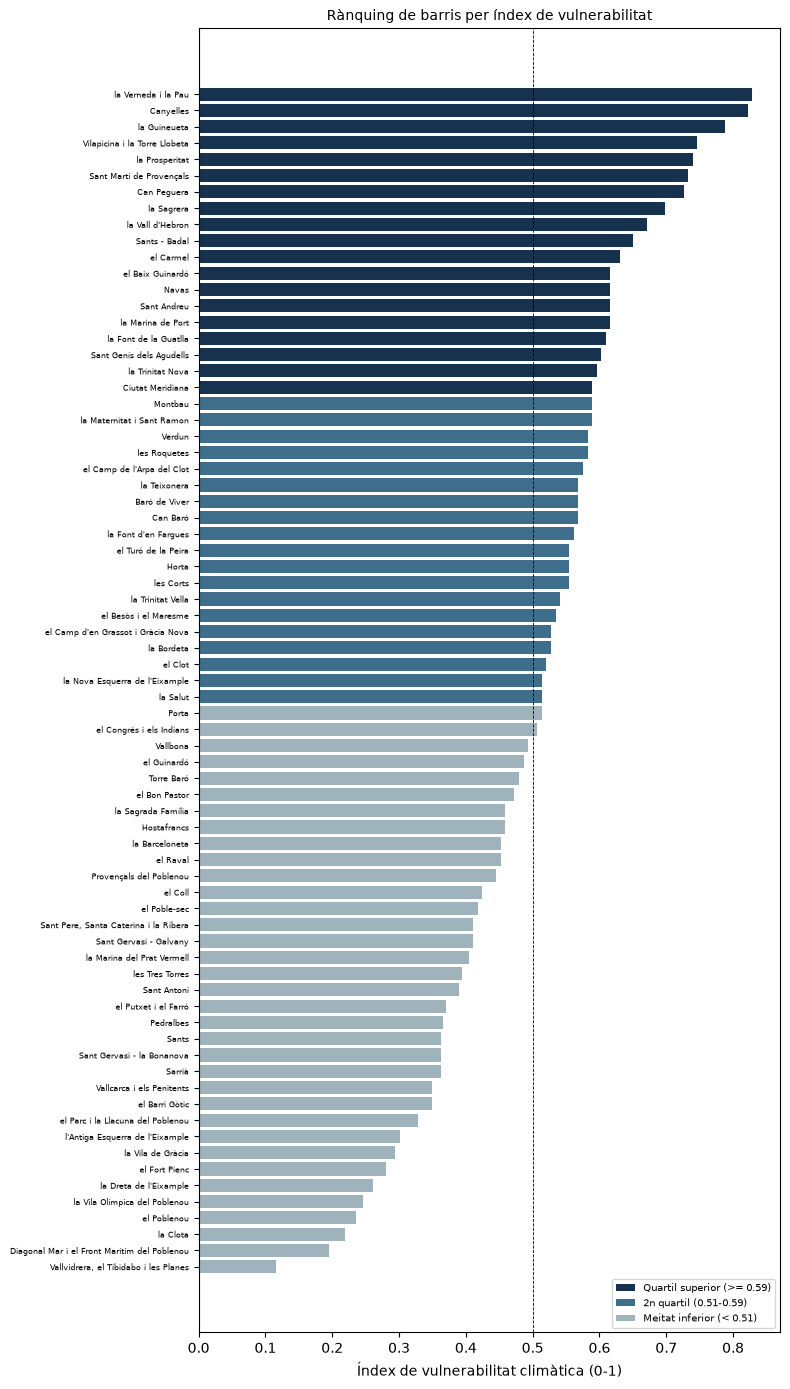

In [37]:
q75, q50 = idx["index_vulnerabilitat"].quantile(0.75), idx["index_vulnerabilitat"].median()
colors = ["#16324F" if v >= q75 else "#3F6E8C" if v >= q50 else "#9FB3BD" for v in idx["index_vulnerabilitat"]]

fig, ax = plt.subplots(figsize=(8, 14))
ax.barh(idx["Nom_Barri"][::-1], idx["index_vulnerabilitat"][::-1], color=colors[::-1])
ax.set_xlabel("Índex de vulnerabilitat climàtica (0-1)")
ax.set_title("Rànquing de barris per índex de vulnerabilitat", fontsize=10)
ax.tick_params(axis="y", labelsize=6)
ax.axvline(0.5, color="black", linewidth=0.6, linestyle="--")
legend_elements = [
    Patch(facecolor="#16324F", label=f"Quartil superior (>= {q75:.2f})"),
    Patch(facecolor="#3F6E8C", label=f"2n quartil ({q50:.2f}-{q75:.2f})"),
    Patch(facecolor="#9FB3BD", label=f"Meitat inferior (< {q50:.2f})"),
]
ax.legend(handles=legend_elements, fontsize=7, loc="lower right")
plt.tight_layout()
plt.show()

## 4. Cobertura de refugis per habitants

Calculem quants refugis climàtics filtrats (gratuïts i d'accés lliure) hi ha per cada 1.000 habitants a cada barri (`taxa_1000_hab`), per identificar quins barris estan millor i pitjor coberts en relació a la seva població.

**Filtre d'outliers per població:** abans de calcular el top/bottom 5, excloem els barris amb menys de 10.000 habitants (16 dels 73, aproximadament el primer quartil de la distribució de població). Amb poblacions tan petites, 1-2 refugis disparen la taxa artificialment — per exemple, Vallbona (1.289 hab.) surt "1r" amb un sol refugi. Sense aquest filtre, tant el top com el bottom queden dominats per aquest efecte de números petits, no per una diferència real de cobertura.

**Cobertura relativa (0-100%):** per fer la taxa més fàcil d'interpretar, la reescalem entre el barri pitjor cobert (0%) i el millor cobert (100%) dins el subconjunt de barris robustos (`cobertura_relativa_pct`). Aquest percentatge és una mètrica relativa pròpia de l'estudi — no és comparable amb el 99,1% de cobertura que publica l'Ajuntament, que es basa en temps de caminada, no en densitat de refugis per habitant.

In [44]:
LLINDAR_POBLACIO = 10000

n_filtrat = (
    refugis_unics[(refugis_unics["Gratuït"] == "Sí") & (refugis_unics["Accés Lliure"] == "Sí")]
    .groupby("Codi_Barri")
    .size()
    .rename("n_refugis_filtrat")
)

cobertura = poblacio[["Codi_Barri", "Nom_Barri", "poblacio_total"]].merge(n_filtrat, on="Codi_Barri", how="left")
cobertura["n_refugis_filtrat"] = cobertura["n_refugis_filtrat"].fillna(0).astype(int)
cobertura["taxa_1000_hab"] = cobertura["n_refugis_filtrat"] / cobertura["poblacio_total"] * 1000

print(cobertura["poblacio_total"].describe())

cobertura_robusta = cobertura[cobertura["poblacio_total"] >= LLINDAR_POBLACIO].copy()
print(f"Barris exclosos per població < {LLINDAR_POBLACIO}: {len(cobertura) - len(cobertura_robusta)} de {len(cobertura)}")

min_taxa = cobertura_robusta["taxa_1000_hab"].min()
max_taxa = cobertura_robusta["taxa_1000_hab"].max()
cobertura_robusta["cobertura_relativa_pct"] = (
    (cobertura_robusta["taxa_1000_hab"] - min_taxa) / (max_taxa - min_taxa) * 100
).round(1)

columnes = ["Nom_Barri", "poblacio_total", "n_refugis_filtrat", "taxa_1000_hab", "cobertura_relativa_pct"]

top5 = cobertura_robusta.nlargest(5, "taxa_1000_hab")[columnes].reset_index(drop=True)
bottom5 = cobertura_robusta.nsmallest(5, "taxa_1000_hab")[columnes].reset_index(drop=True)


def estil_taula(df, color, caption):
    return (
        df.style
        .apply(lambda row: [f"background-color: {color}; color: #2c2c2a"] * len(row), axis=1)
        .format({
            "poblacio_total": lambda x: f"{x:,.0f}".replace(",", "."),
            "taxa_1000_hab": "{:.2f}",
            "cobertura_relativa_pct": "{:.1f}%",
        })
        .hide(axis="index")
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#4a4a4a"), ("color", "white"),
                ("padding", "6px 10px"), ("text-align", "center"), ("white-space", "nowrap"),
            ]},
            {"selector": "td", "props": [
                ("padding", "6px 10px"), ("text-align", "center"), ("border", "1px solid #ddd"),
                ("white-space", "nowrap"),
            ]},
            {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "11px"), ("padding-bottom", "6px")]},
        ])
        .set_caption(caption)
    )


taula_top5 = estil_taula(
    top5, "#7BA07E",
    f"Top 5 barris amb més cobertura real, població ≥ {LLINDAR_POBLACIO:,}".replace(",", "."),
)
taula_bottom5 = estil_taula(
    bottom5, "#C9772F",
    f"Bottom 5 barris amb menys cobertura real, població ≥ {LLINDAR_POBLACIO:,}".replace(",", "."),
)

display(taula_top5)
display(taula_bottom5)

count      73.00
mean    23604.25
std     15062.11
min       944.00
25%     11483.00
50%     22581.00
75%     31693.00
max     59199.00
Name: poblacio_total, dtype: float64
Barris exclosos per població < 10000: 16 de 73


Nom_Barri,poblacio_total,n_refugis_filtrat,taxa_1000_hab,cobertura_relativa_pct
la Trinitat Vella,11.283,5,0.44,100.0%
la Barceloneta,14.471,6,0.41,93.6%
la Maternitat i Sant Ramon,24.565,8,0.33,73.5%
Vallcarca i els Penitents,16.781,5,0.30,67.2%
el Poble-sec,40.021,11,0.27,62.0%


Nom_Barri,poblacio_total,n_refugis_filtrat,taxa_1000_hab,cobertura_relativa_pct
l'Antiga Esquerra de l'Eixample,42.726,0,0.00,0.0%
el Clot,26.850,1,0.04,8.4%
Sants - Badal,25.201,1,0.04,9.0%
Navas,22.581,1,0.04,10.0%
Provençals del Poblenou,21.999,1,0.05,10.3%


## 5. Correlació vulnerabilitat vs. cobertura real, i barris de risc

Estem comparant, pels 57 barris que han passat el filtre de població, dues variables per barri: `index_vulnerabilitat` (0 = menys vulnerable, 1 = més vulnerable) i `cobertura_relativa_pct` (0 = pitjor coberta, 100 = millor coberta).

**H0**: no existeix relació entre la vulnerabilitat d'un barri i la seva cobertura de refugis.

**H1**: existeix relació entre vulnerabilitat i cobertura.

**Tria del test:** fem servir la correlació de Spearman en lloc de Pearson perquè cap de les dues variables és normal: `index_vulnerabilitat` és una mitjana de dos percentils, i `cobertura_relativa_pct` prové d'una taxa esbiaixada (molts barris amb valors baixos i pocs amb valors alts). 

**Resultat:** ρ = -0,04, p-valor = 0,766. Com que p ≥ 0,05, no rebutgem H0: en aquesta mostra no hi ha evidència d'una relació entre la vulnerabilitat d'un barri i la seva cobertura real de refugis climàtics.

**Gràfic de quadrants:** per complementar el test numèric amb una lectura visual, dividim els 57 barris en 4 grups a partir de la mediana de cada variable: 

- crític (molt vulnerable + poca cobertura, vermell) 
- vulnerable però ben cobert (blau)
- favorable (poc vulnerable + bona cobertura, verd)
- baixa prioritat (poc vulnerable + poca cobertura, gris)

La dispersió dels quatre colors pel gràfic, sense cap patró clar, reforça visualment el resultat del test: la cobertura de refugis no depèn de la vulnerabilitat del barri.

Barris inclosos en la correlació: 57 de 73 (només els que superen el llindar de població)

Correlació de Spearman: rho = -0.040, p-valor = 0.7660, n = 57
p-valor >= 0.05 -> no rebutgem H0. No hi ha prou evidència d'una relació entre vulnerabilitat i cobertura de refugis en aquesta mostra.


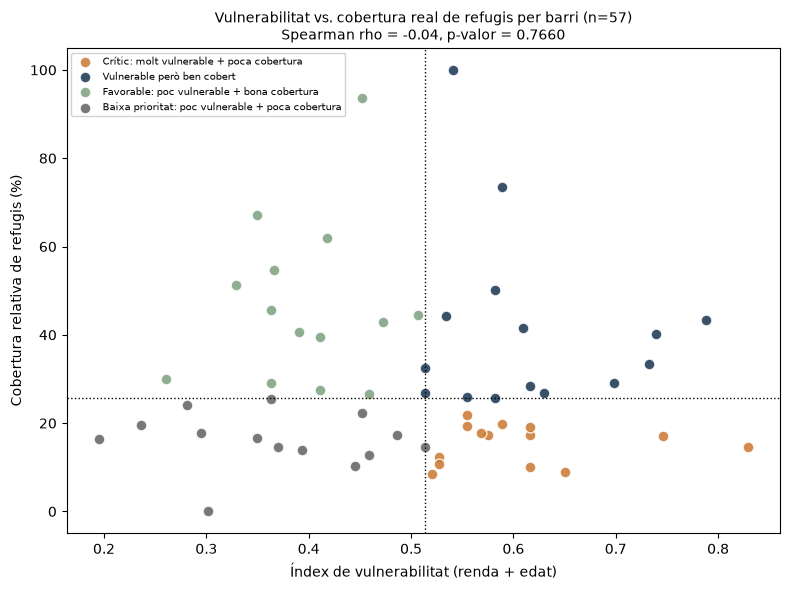

In [50]:
ALPHA = 0.05

vuln_cobertura = idx[["Codi_Barri", "Nom_Barri", "index_vulnerabilitat"]].merge(
    cobertura_robusta[["Codi_Barri", "poblacio_total", "taxa_1000_hab", "cobertura_relativa_pct"]],
    on="Codi_Barri",
    how="inner",
)

print(f"Barris inclosos en la correlació: {len(vuln_cobertura)} de {len(idx)} "
      f"(només els que superen el llindar de població)")

rho, p_valor = spearmanr(vuln_cobertura["index_vulnerabilitat"], vuln_cobertura["cobertura_relativa_pct"])

print(f"\nCorrelació de Spearman: rho = {rho:.3f}, p-valor = {p_valor:.4f}, n = {len(vuln_cobertura)}")

if p_valor < ALPHA:
    direccio = "negativa (a més vulnerabilitat, menys cobertura)" if rho < 0 else "positiva (a més vulnerabilitat, més cobertura)"
    print(f"p-valor < {ALPHA} -> rebutgem H0. Hi ha una relació {direccio}, estadísticament significativa.")
else:
    print(f"p-valor >= {ALPHA} -> no rebutgem H0. No hi ha prou evidència d'una relació "
          f"entre vulnerabilitat i cobertura de refugis en aquesta mostra.")


mediana_vuln = vuln_cobertura["index_vulnerabilitat"].median()
mediana_cobertura = vuln_cobertura["cobertura_relativa_pct"].median()


def classifica_quadrant(row):
    alta_vuln = row["index_vulnerabilitat"] >= mediana_vuln
    alta_cob = row["cobertura_relativa_pct"] >= mediana_cobertura
    if alta_vuln and not alta_cob:
        return "Crític: molt vulnerable + poca cobertura"
    if alta_vuln and alta_cob:
        return "Vulnerable però ben cobert"
    if not alta_vuln and alta_cob:
        return "Favorable: poc vulnerable + bona cobertura"
    return "Baixa prioritat: poc vulnerable + poca cobertura"


vuln_cobertura["situacio"] = vuln_cobertura.apply(classifica_quadrant, axis=1)

colors_quadrant = {
    "Crític: molt vulnerable + poca cobertura": "#C9772F",
    "Vulnerable però ben cobert": "#16324F",
    "Favorable: poc vulnerable + bona cobertura": "#7BA07E",
    "Baixa prioritat: poc vulnerable + poca cobertura": "#606060",
}

fig, ax = plt.subplots(figsize=(8, 6))
for situacio, color in colors_quadrant.items():
    subset = vuln_cobertura[vuln_cobertura["situacio"] == situacio]
    ax.scatter(
        subset["index_vulnerabilitat"], subset["cobertura_relativa_pct"],
        color=color, alpha=0.85, edgecolor="white", s=60, label=situacio,
    )

ax.axvline(mediana_vuln, color="black", linestyle=":", linewidth=1)
ax.axhline(mediana_cobertura, color="black", linestyle=":", linewidth=1)

ax.set_xlabel("Índex de vulnerabilitat (renda + edat)")
ax.set_ylabel("Cobertura relativa de refugis (%)")
ax.set_title(
    f"Vulnerabilitat vs. cobertura real de refugis per barri (n={len(vuln_cobertura)})\n"
    f"Spearman rho = {rho:.2f}, p-valor = {p_valor:.4f}",
    fontsize=10,
)
ax.legend(loc="upper left", fontsize=7, framealpha=0.9)
plt.tight_layout()
plt.show()
 

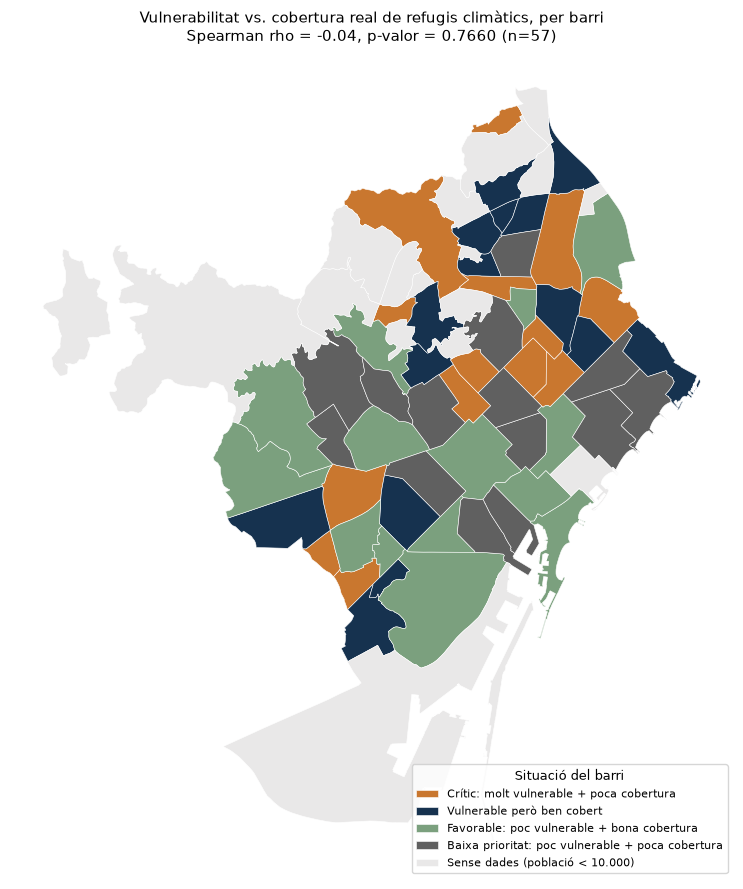

In [51]:
barris_gdf = gpd.read_file(DATA / "04_barris_geo_espacial.geojson")
barris_gdf = barris_gdf[["BARRI", "geometry"]].rename(columns={"BARRI": "Codi_Barri"})
barris_gdf["Codi_Barri"] = barris_gdf["Codi_Barri"].astype(int)

mapa_dades = barris_gdf.merge(
    vuln_cobertura[["Codi_Barri", "situacio"]],
    on="Codi_Barri",
    how="left",
)
mapa_dades["situacio"] = mapa_dades["situacio"].fillna("Sense dades (població < 10.000)")

colors_mapa = {**colors_quadrant, "Sense dades (població < 10.000)": "#e9e8e8"}
ordre_situacio = list(colors_mapa.keys())
mapa_dades["situacio"] = pd.Categorical(mapa_dades["situacio"], categories=ordre_situacio, ordered=True)

fig, ax = plt.subplots(figsize=(9, 9))
for situacio, color in colors_mapa.items():
    subset = mapa_dades[mapa_dades["situacio"] == situacio]
    if len(subset) == 0:
        continue
    subset.plot(ax=ax, color=color, edgecolor="white", linewidth=0.4, label=situacio)

ax.set_title(
    f"Vulnerabilitat vs. cobertura real de refugis climàtics, per barri\n"
    f"Spearman rho = {rho:.2f}, p-valor = {p_valor:.4f} (n={len(vuln_cobertura)})",
    fontsize=11,
)
ax.axis("off")
ax.legend(loc="lower right", fontsize=8, title="Situació del barri", title_fontsize=9)
plt.tight_layout()
plt.show()

Els barris crítics (molt vulnerables i amb poca cobertura real) són la Verneda i la Pau, Vilapicina i la Torre Llobeta, Sants-Badal, el Baix Guinardó, Navas, Sant Andreu, Ciutat Meridiana, el Camp de l'Arpa del Clot, la Teixonera, Horta, les Corts, el Camp d'en Grassot i Gràcia Nova, la Bordeta i el Clot. Tot i que el test de Spearman no troba relació significativa a escala de ciutat (ρ = -0,04, p = 0,766), aquests 14 barris apareixen dispersos en districtes diferents, no concentrats en un de sol — el risc és puntual, no un patró general de tota Barcelona.

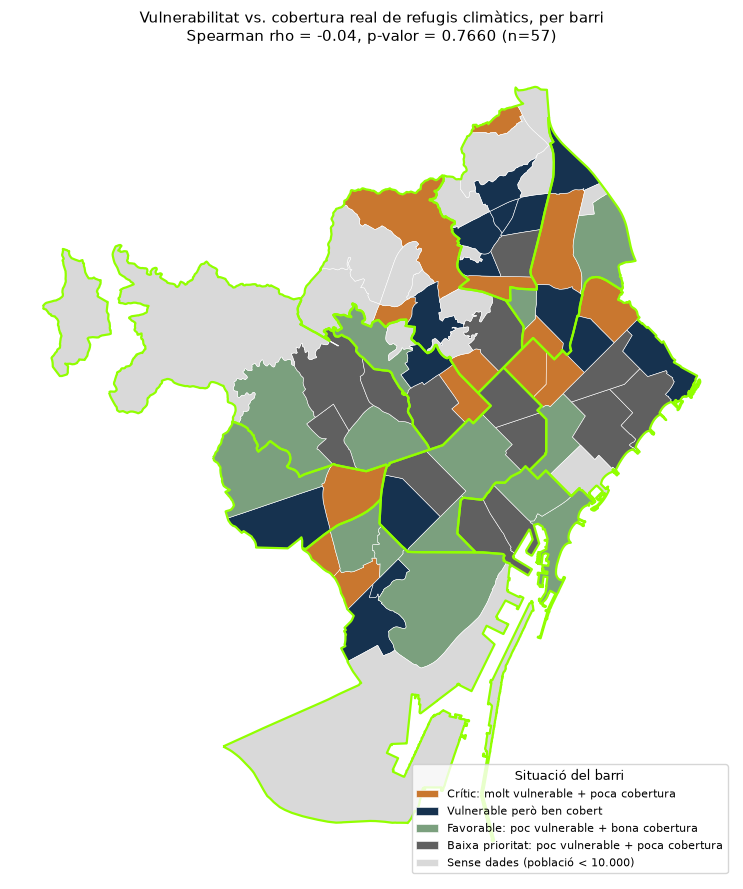

In [67]:
barris_raw = gpd.read_file(DATA / "04_barris_geo_espacial.geojson")

columnes_districte = [c for c in barris_raw.columns if "distric" in c.lower()]
if not columnes_districte:
    print("Columnes disponibles al geojson:", barris_raw.columns.tolist())
    raise ValueError(
        "No he trobat cap columna de districte al geojson. Mira la llista de columnes de sobre "
        "i digue'm quin és el nom exacte per adaptar el codi."
    )
col_districte = columnes_districte[0]

barris_gdf = barris_raw[["BARRI", col_districte, "geometry"]].rename(
    columns={"BARRI": "Codi_Barri", col_districte: "Codi_Districte"}
)
barris_gdf["Codi_Barri"] = barris_gdf["Codi_Barri"].astype(int)

districtes_gdf = barris_gdf.dissolve(by="Codi_Districte")

mapa_dades = barris_gdf.merge(
    vuln_cobertura[["Codi_Barri", "situacio"]],
    on="Codi_Barri",
    how="left",
)
mapa_dades["situacio"] = mapa_dades["situacio"].fillna("Sense dades (població < 10.000)")

colors_mapa = {**colors_quadrant, "Sense dades (població < 10.000)": "#d9d9d9"}
ordre_situacio = list(colors_mapa.keys())
mapa_dades["situacio"] = pd.Categorical(mapa_dades["situacio"], categories=ordre_situacio, ordered=True)

fig, ax = plt.subplots(figsize=(9, 9))
for situacio, color in colors_mapa.items():
    subset = mapa_dades[mapa_dades["situacio"] == situacio]
    if len(subset) == 0:
        continue
    subset.plot(ax=ax, color=color, edgecolor="white", linewidth=0.4, label=situacio)

districtes_gdf.boundary.plot(ax=ax, color="#91FF00", linewidth=1.6)

ax.set_title(
    f"Vulnerabilitat vs. cobertura real de refugis climàtics, per barri\n"
    f"Spearman rho = {rho:.2f}, p-valor = {p_valor:.4f} (n={len(vuln_cobertura)})",
    fontsize=11,
)
ax.axis("off")
ax.legend(loc="lower right", fontsize=8, title="Situació del barri", title_fontsize=9)
plt.tight_layout()
plt.show()

Com es plantejava a l'inici, agregar les dades a escala de districte amagaria situacions de risc real: 5 dels 10 districtes de Barcelona (Sants-Montjuïc, les Corts, Gràcia, Sant Andreu i Sant Martí) contenen alhora com a mínim un barri en situació crítica (molt vulnerable + poca cobertura) i un altre en situació favorable. A més, 8 dels 10 districtes combinen tres o quatre situacions diferents entre els seus barris — Gràcia i Sant Martí en són els casos més extrems, amb les quatre situacions presents alhora; només Ciutat Vella i Sarrià-Sant Gervasi mostren un mínim d'homogeneïtat (dues situacions). Un indicador mitjà de districte donaria una falsa sensació de cobertura homogènia, quan en realitat conviuen barris amb necessitats molt diferents dins del mateix territori administratiu — el que reforça la necessitat de treballar a escala de barri, no de districte, per detectar zones de risc.

## 6. Barris exclosos per volum de població: anàlisi complementari

Els 16 barris amb població inferior a 10.000 habitants (aproximadament el primer quartil de la distribució) es van excloure de la correlació de Spearman principal perquè, amb denominadors tan petits, la taxa de cobertura de refugis per habitant es torna extremadament inestable: un sol refugi real pot disparar artificialment la taxa d'un barri (cas de Vallbona, 1.289 hab.), distorsionant qualsevol comparació amb barris de mida normal.

Per no deixar-los fora de l'anàlisi, es tracten per separat amb un criteri adaptat a la seva mida. En lloc d'una taxa contínua, es fa servir un indicador binari —el barri té almenys un refugi climàtic real (gratuït i d'accés lliure), sí o no—, que no depèn de dividir per una població petita i per tant no pateix el mateix problema d'inestabilitat. 

Aquest indicador es combina amb el mateix index_vulnerabilitat (basat en percentils de renda i edat, calculat sobre els 73 barris) per obtenir quatre categories anàlogues a les de l'anàlisi principal: crític (vulnerable i sense refugi), cobert (vulnerable amb refugi), baixa prioritat (poc vulnerable i sense refugi) i favorable (poc vulnerable amb refugi).


In [57]:
n_filtrat_petits = (
    refugis_unics[(refugis_unics["Gratuït"] == "Sí") & (refugis_unics["Accés Lliure"] == "Sí")]
    .groupby("Codi_Barri")
    .size()
    .rename("n_refugis_filtrat")
)

barris_petits = poblacio[poblacio["poblacio_total"] < LLINDAR_POBLACIO][
    ["Codi_Barri", "Nom_Barri", "poblacio_total"]
].copy()

barris_petits = barris_petits.merge(n_filtrat_petits, on="Codi_Barri", how="left")
barris_petits["n_refugis_filtrat"] = barris_petits["n_refugis_filtrat"].fillna(0).astype(int)
barris_petits["te_refugi"] = barris_petits["n_refugis_filtrat"] > 0

barris_petits = barris_petits.merge(
    idx[["Codi_Barri", "index_vulnerabilitat"]], on="Codi_Barri", how="left"
)

llindar_vuln = idx["index_vulnerabilitat"].median()
barris_petits["vulnerable"] = barris_petits["index_vulnerabilitat"] >= llindar_vuln

def classifica(row):
    if row["vulnerable"] and not row["te_refugi"]:
        return "Crític: vulnerable + sense refugi"
    if row["vulnerable"] and row["te_refugi"]:
        return "Cobert: vulnerable + amb refugi"
    if not row["vulnerable"] and not row["te_refugi"]:
        return "Baixa prioritat: poc vulnerable + sense refugi"
    return "Favorable: poc vulnerable + amb refugi"

barris_petits["situacio"] = barris_petits.apply(classifica, axis=1)

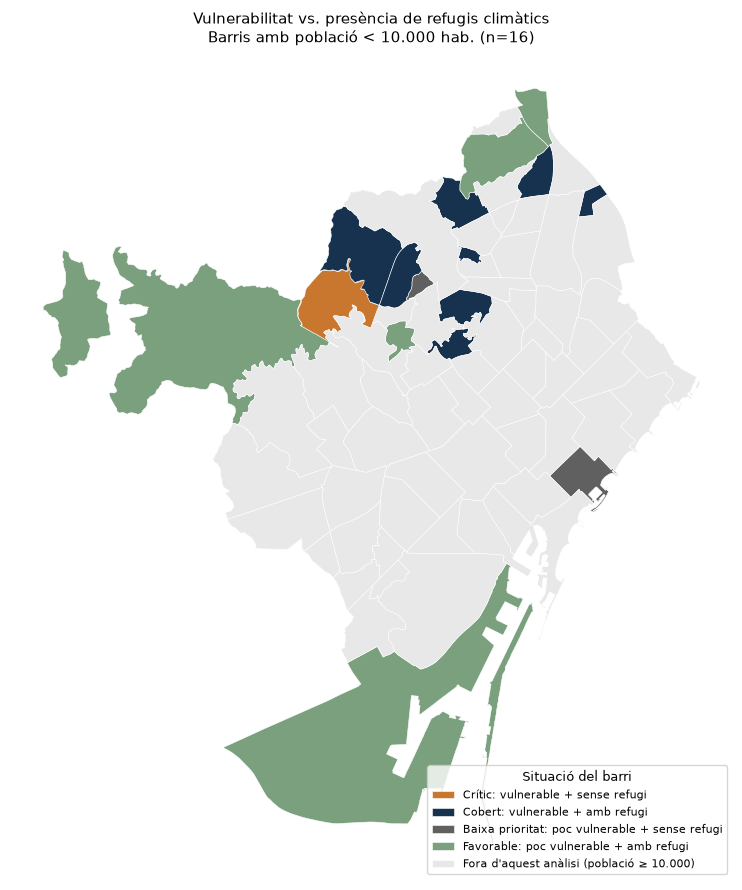

In [60]:
barris_gdf = gpd.read_file(DATA / "04_barris_geo_espacial.geojson")
barris_gdf = barris_gdf[["BARRI", "geometry"]].rename(columns={"BARRI": "Codi_Barri"})
barris_gdf["Codi_Barri"] = barris_gdf["Codi_Barri"].astype(int)

mapa_petits = barris_gdf.merge(
    barris_petits[["Codi_Barri", "situacio"]],
    on="Codi_Barri",
    how="left",
)
mapa_petits["situacio"] = mapa_petits["situacio"].fillna("Fora d'aquest anàlisi (població ≥ 10.000)")

colors_barris_petits = {
    "Crític: vulnerable + sense refugi": "#C9772F",
    "Cobert: vulnerable + amb refugi": "#16324F",
    "Baixa prioritat: poc vulnerable + sense refugi": "#606060",
    "Favorable: poc vulnerable + amb refugi": "#7BA07E",
    "Fora d'aquest anàlisi (població ≥ 10.000)": "#e9e8e8",
}
ordre_situacio = list(colors_barris_petits.keys())
mapa_petits["situacio"] = pd.Categorical(mapa_petits["situacio"], categories=ordre_situacio, ordered=True)

fig, ax = plt.subplots(figsize=(9, 9))
for situacio, color in colors_barris_petits.items():
    subset = mapa_petits[mapa_petits["situacio"] == situacio]
    if len(subset) == 0:
        continue
    subset.plot(ax=ax, color=color, edgecolor="white", linewidth=0.4, label=situacio)

ax.set_title(
    f"Vulnerabilitat vs. presència de refugis climàtics\n"
    f"Barris amb població < 10.000 hab. (n={len(barris_petits)})",
    fontsize=11,
)
ax.axis("off")
ax.legend(loc="lower right", fontsize=8, title="Situació del barri", title_fontsize=9)
plt.tight_layout()
plt.show()

Resultats. Dels 16 barris amb població inferior a 10.000 habitants, un únic barri —Sant Genís dels Agudells (7.882 hab.)— es classifica com a crític: vulnerable segons l'índex i sense cap refugi climàtic real registrat.

Vuit barris (Can Baró, la Font d'en Fargues, Montbau, la Vall d'Hebron, Can Peguera, Canyelles, la Trinitat Nova i Baró de Viver) són vulnerables però compten amb almenys un refugi real. 

Cinc barris (la Marina del Prat Vermell, Vallvidrera-el Tibidabo i les Planes, el Coll, Torre Baró i Vallbona) es troben en situació favorable, poc vulnerables i amb refugi. 

Els dos restants (la Clota i la Vila Olímpica del Poblenou) queden en baixa prioritat: sense refugi, però tampoc especialment vulnerables.


La majoria d'aquests 16 barris petits no presenten risc crític. Només Sant Genís dels Agudells combina alta vulnerabilitat i absència total de cobertura, i mereixeria atenció malgrat quedar fora del llindar estadístic de població que exclou la resta de l'anàlisi.